# SafeType — Exploratory Data Analysis (EDA)

This notebook explores the datasets used in the SafeType project, providing visual insights that motivate the modeling and feature engineering decisions made in our pipeline.

**Sections:**
1. Dataset Overview & Class Distribution
2. Text Length Analysis by Category
3. High-Frequency Words & Word Clouds
4. TF-IDF Feature Analysis
5. Handcrafted Features Analysis
6. Data Source Comparison
7. Error Analysis Preview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from scipy import sparse
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {"clean": "#10b981", "offensive": "#f59e0b", "hate_speech": "#ef4444"}
PALETTE = [COLORS["clean"], COLORS["offensive"], COLORS["hate_speech"]]

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")

unified = pd.read_csv(DATA_DIR / "processed" / "unified_toxicity_data.csv")
balanced = pd.read_csv(DATA_DIR / "processed" / "balanced_toxicity_data.csv")
train_df = pd.read_csv(DATA_DIR / "processed" / "train.csv")
test_df = pd.read_csv(DATA_DIR / "processed" / "test.csv")

print(f"Unified dataset: {len(unified):,} samples")
print(f"Balanced dataset: {len(balanced):,} samples")
print(f"Train set: {len(train_df):,} | Test set: {len(test_df):,}")

Unified dataset: 284,021 samples
Balanced dataset: 16,986 samples
Train set: 13,588 | Test set: 3,398


## 1. Dataset Overview & Class Distribution

We combined three data sources: Davidson hate speech dataset, Jigsaw v1, and Jigsaw v2. The raw combined data is heavily imbalanced — "clean" dominates. This motivates the balanced sampling strategy in `make_dataset.py`.

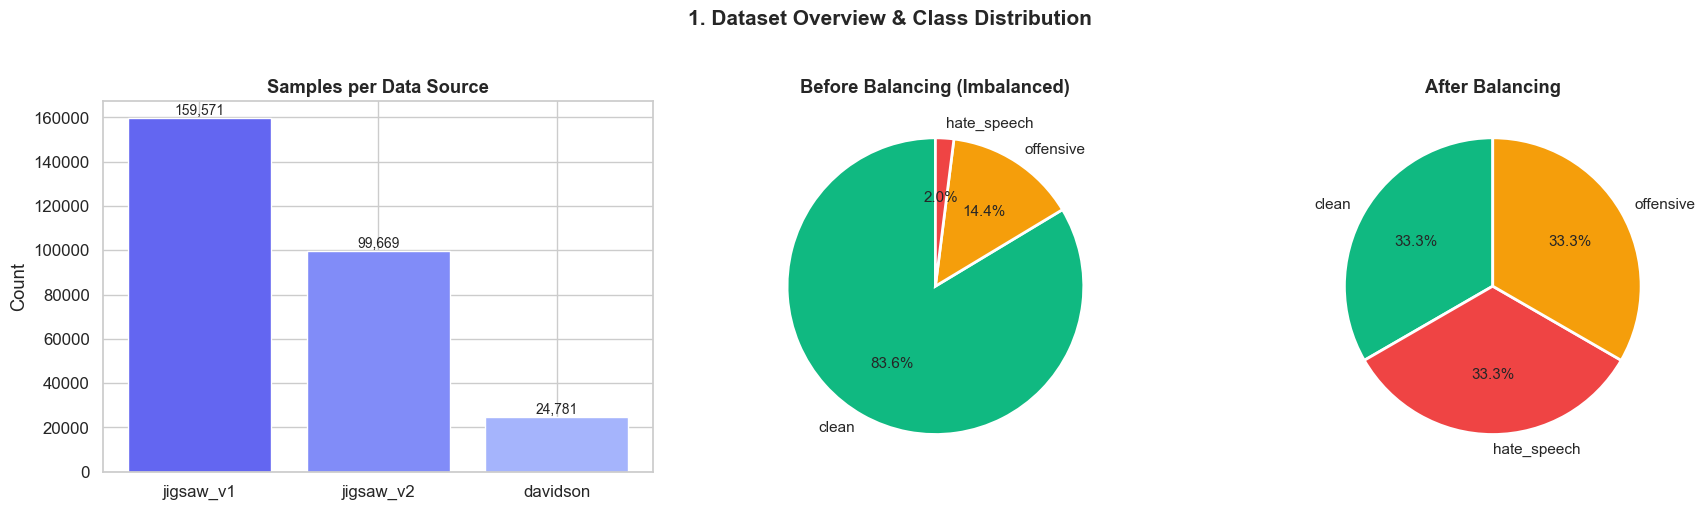

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a — Per-source sample counts
source_counts = unified["source"].value_counts()
bars = axes[0].bar(source_counts.index, source_counts.values, color=["#6366f1", "#818cf8", "#a5b4fc"], edgecolor="white")
axes[0].set_title("Samples per Data Source", fontweight="bold")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, source_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1500, f"{v:,}", ha="center", fontsize=10)

# 1b — Unified (imbalanced) label distribution
label_counts = unified["label"].value_counts()
axes[1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%",
            colors=[COLORS[l] for l in label_counts.index], startangle=90,
            textprops={"fontsize": 11}, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Before Balancing (Imbalanced)", fontweight="bold")

# 1c — Balanced label distribution
bal_counts = balanced["label"].value_counts()
axes[2].pie(bal_counts.values, labels=bal_counts.index, autopct="%1.1f%%",
            colors=[COLORS[l] for l in bal_counts.index], startangle=90,
            textprops={"fontsize": 11}, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[2].set_title("After Balancing", fontweight="bold")

plt.suptitle("1. Dataset Overview & Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

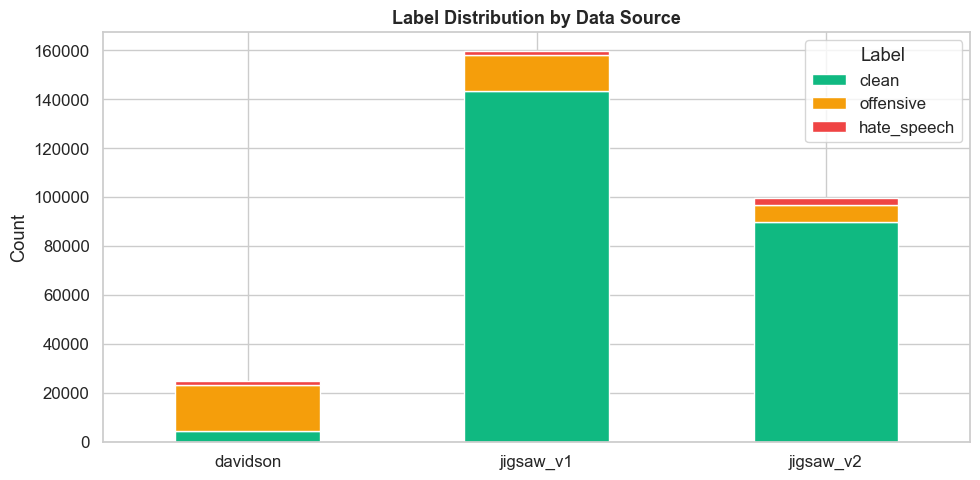


Cross-tabulation:
label       clean  offensive  hate_speech
source                                   
davidson     4163      19189         1429
jigsaw_v1  143346      14820         1405
jigsaw_v2   90013       6828         2828

Imbalance ratio (clean / hate_speech): 42.0x


In [3]:
# 1d — Label distribution breakdown per source (stacked bar)
cross = pd.crosstab(unified["source"], unified["label"])
cross = cross[["clean", "offensive", "hate_speech"]]

fig, ax = plt.subplots(figsize=(10, 5))
cross.plot(kind="bar", stacked=True, color=PALETTE, edgecolor="white", ax=ax)
ax.set_title("Label Distribution by Data Source", fontweight="bold", fontsize=13)
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.legend(title="Label", frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCross-tabulation:")
print(cross)
print(f"\nImbalance ratio (clean / hate_speech): {unified['label'].value_counts()['clean'] / unified['label'].value_counts()['hate_speech']:.1f}x")

## 2. Text Length Analysis

Text length (characters and words) can differ significantly across categories. This analysis validates our handcrafted features (`char_count`, `word_count`, `avg_word_len`) in `build_features.py` and confirms that DistilBERT's `max_len=128` tokens is sufficient.

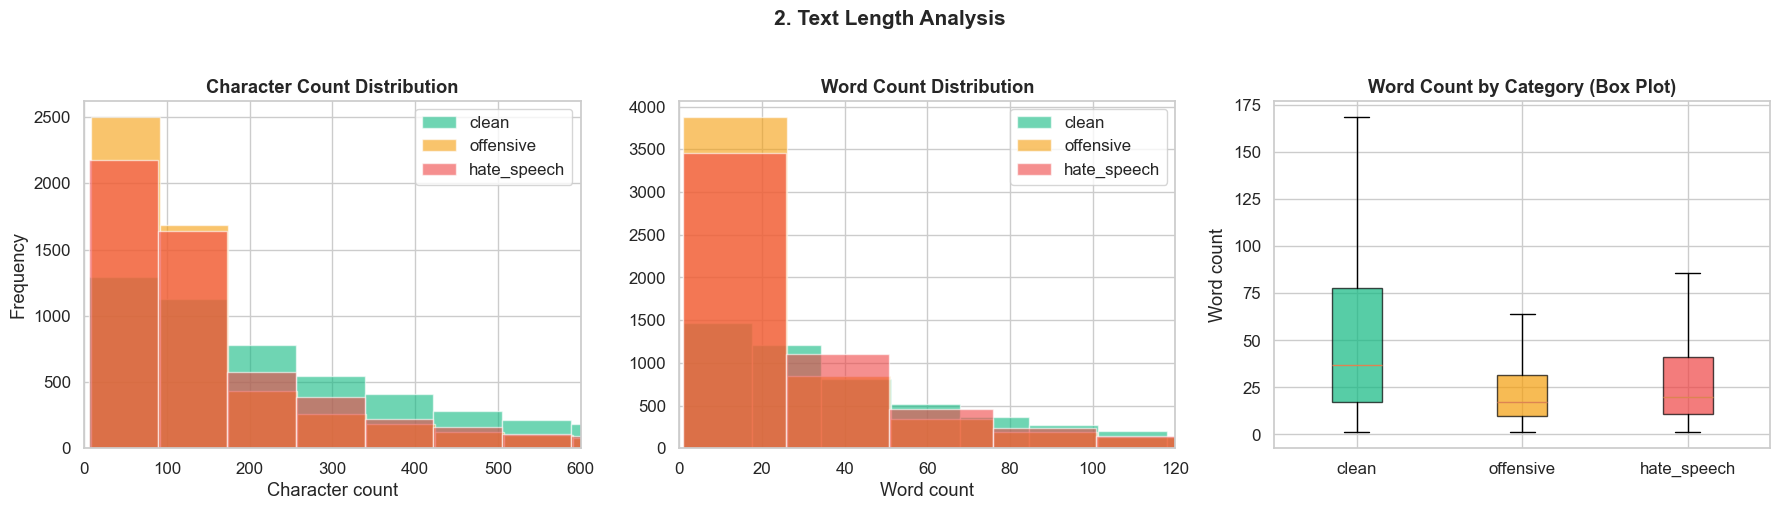

In [4]:
balanced["char_count"] = balanced["text"].str.len()
balanced["word_count"] = balanced["text"].str.split().str.len()
balanced["avg_word_len"] = balanced["char_count"] / balanced["word_count"].clip(lower=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2a — Character count distribution
for label in ["clean", "offensive", "hate_speech"]:
    subset = balanced[balanced["label"] == label]["char_count"]
    axes[0].hist(subset, bins=60, alpha=0.6, label=label, color=COLORS[label], edgecolor="white")
axes[0].set_title("Character Count Distribution", fontweight="bold")
axes[0].set_xlabel("Character count")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].set_xlim(0, 600)

# 2b — Word count distribution
for label in ["clean", "offensive", "hate_speech"]:
    subset = balanced[balanced["label"] == label]["word_count"]
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=COLORS[label], edgecolor="white")
axes[1].set_title("Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Word count")
axes[1].legend()
axes[1].set_xlim(0, 120)

# 2c — Box plot of word count per label
bp_data = [balanced[balanced["label"] == l]["word_count"].dropna() for l in ["clean", "offensive", "hate_speech"]]
bp = axes[2].boxplot(bp_data, labels=["clean", "offensive", "hate_speech"], patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title("Word Count by Category (Box Plot)", fontweight="bold")
axes[2].set_ylabel("Word count")

plt.suptitle("2. Text Length Analysis", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

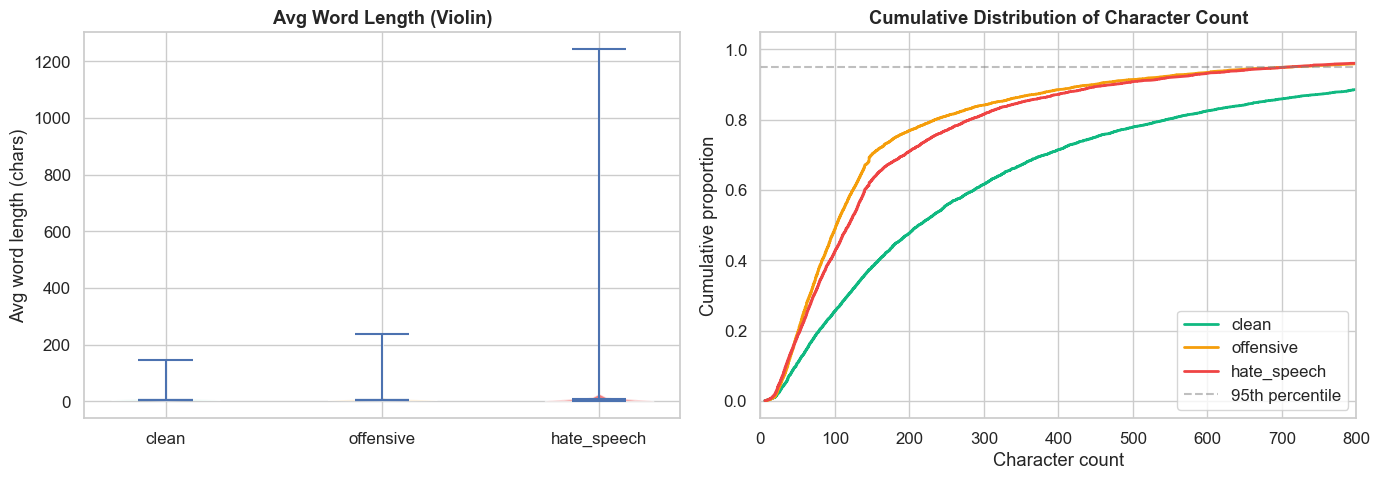

Text length stats by label:
label                clean  hate_speech  offensive
char_count   count  5662.0       5662.0     5662.0
             mean    378.0        216.8      208.7
             std     529.8        388.3      426.1
             min       6.0          6.0        8.0
             25%      98.0         63.0       58.0
             50%     213.0        118.0      102.0
             75%     449.0        230.0      182.0
             max    5000.0       5000.0     5000.0
word_count   count  5662.0       5662.0     5662.0
             mean     64.5         37.4       36.2
             std      87.9         64.9       75.2
             min       1.0          1.0        1.0
             25%      17.0         11.0       10.0
             50%      37.0         20.0       17.0
             75%      78.0         41.0       31.8
             max     836.0       1247.0     1250.0
avg_word_len count  5662.0       5662.0     5662.0
             mean      6.0          6.3        6.0
   

In [5]:
# 2d — Violin plot for avg word length & cumulative distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
parts = axes[0].violinplot(
    [balanced[balanced["label"] == l]["avg_word_len"].dropna() for l in ["clean", "offensive", "hate_speech"]],
    positions=[1, 2, 3], showmeans=True, showmedians=True
)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(PALETTE[i])
    pc.set_alpha(0.7)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["clean", "offensive", "hate_speech"])
axes[0].set_title("Avg Word Length (Violin)", fontweight="bold")
axes[0].set_ylabel("Avg word length (chars)")

# CDF of character count
for label in ["clean", "offensive", "hate_speech"]:
    subset = balanced[balanced["label"] == label]["char_count"].sort_values()
    cdf = np.arange(1, len(subset)+1) / len(subset)
    axes[1].plot(subset, cdf, label=label, color=COLORS[label], linewidth=2)
axes[1].axhline(y=0.95, color="gray", linestyle="--", alpha=0.5, label="95th percentile")
axes[1].set_title("Cumulative Distribution of Character Count", fontweight="bold")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Cumulative proportion")
axes[1].legend()
axes[1].set_xlim(0, 800)

plt.tight_layout()
plt.show()

# Summary stats
print("Text length stats by label:")
print(balanced.groupby("label")[["char_count", "word_count", "avg_word_len"]].describe().round(1).T)

## 3. High-Frequency Words & Word Clouds

Examining the most common words in each category helps us understand: (a) why the Naive Baseline keyword list works for some cases, and (b) what patterns TF-IDF and DistilBERT can leverage.

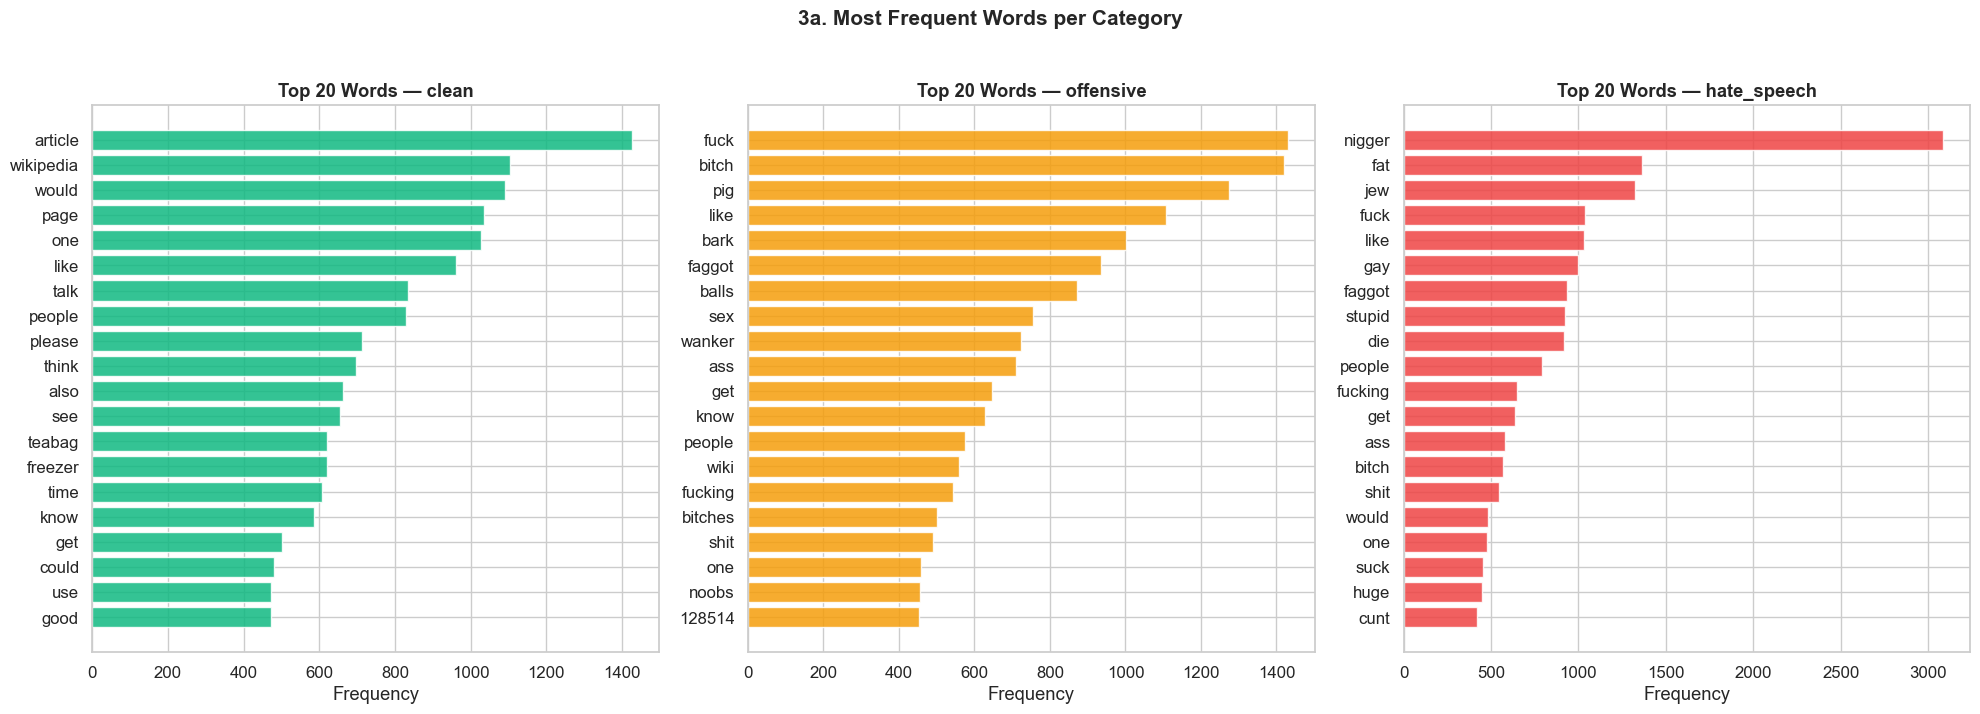

In [6]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def get_top_words(texts, n=20):
    words = []
    for t in texts:
        t = re.sub(r"[^\w\s]", " ", str(t).lower())
        words.extend([w for w in t.split() if w not in stop_words and len(w) > 2])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for i, label in enumerate(["clean", "offensive", "hate_speech"]):
    subset = balanced[balanced["label"] == label]["text"]
    top = get_top_words(subset, 20)
    words, counts = zip(*top)
    y_pos = range(len(words))
    axes[i].barh(y_pos, counts, color=COLORS[label], edgecolor="white", alpha=0.85)
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f"Top 20 Words — {label}", fontweight="bold")
    axes[i].set_xlabel("Frequency")

plt.suptitle("3a. Most Frequent Words per Category", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

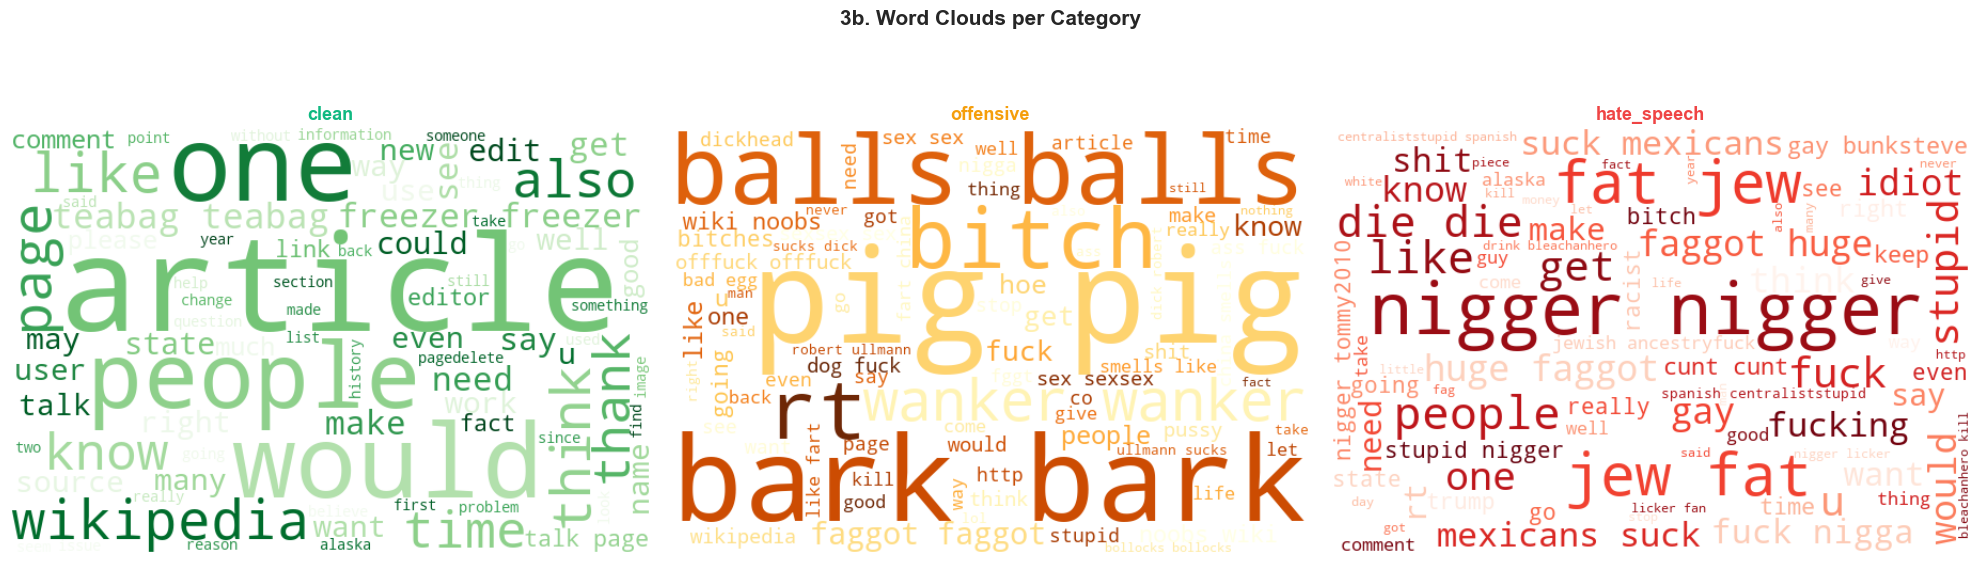

In [7]:
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("wordcloud not installed. Run: pip install wordcloud")

if HAS_WORDCLOUD:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for i, label in enumerate(["clean", "offensive", "hate_speech"]):
        subset = balanced[balanced["label"] == label]["text"]
        text_blob = " ".join(
            re.sub(r"[^\w\s]", " ", str(t).lower())
            for t in subset
        )
        wc = WordCloud(
            width=600, height=400, background_color="white",
            colormap={"clean": "Greens", "offensive": "YlOrBr", "hate_speech": "Reds"}[label],
            stopwords=stop_words, max_words=80, contour_width=2,
            contour_color=COLORS[label],
        ).generate(text_blob)
        axes[i].imshow(wc, interpolation="bilinear")
        axes[i].set_title(f"{label}", fontweight="bold", fontsize=13, color=COLORS[label])
        axes[i].axis("off")

    plt.suptitle("3b. Word Clouds per Category", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

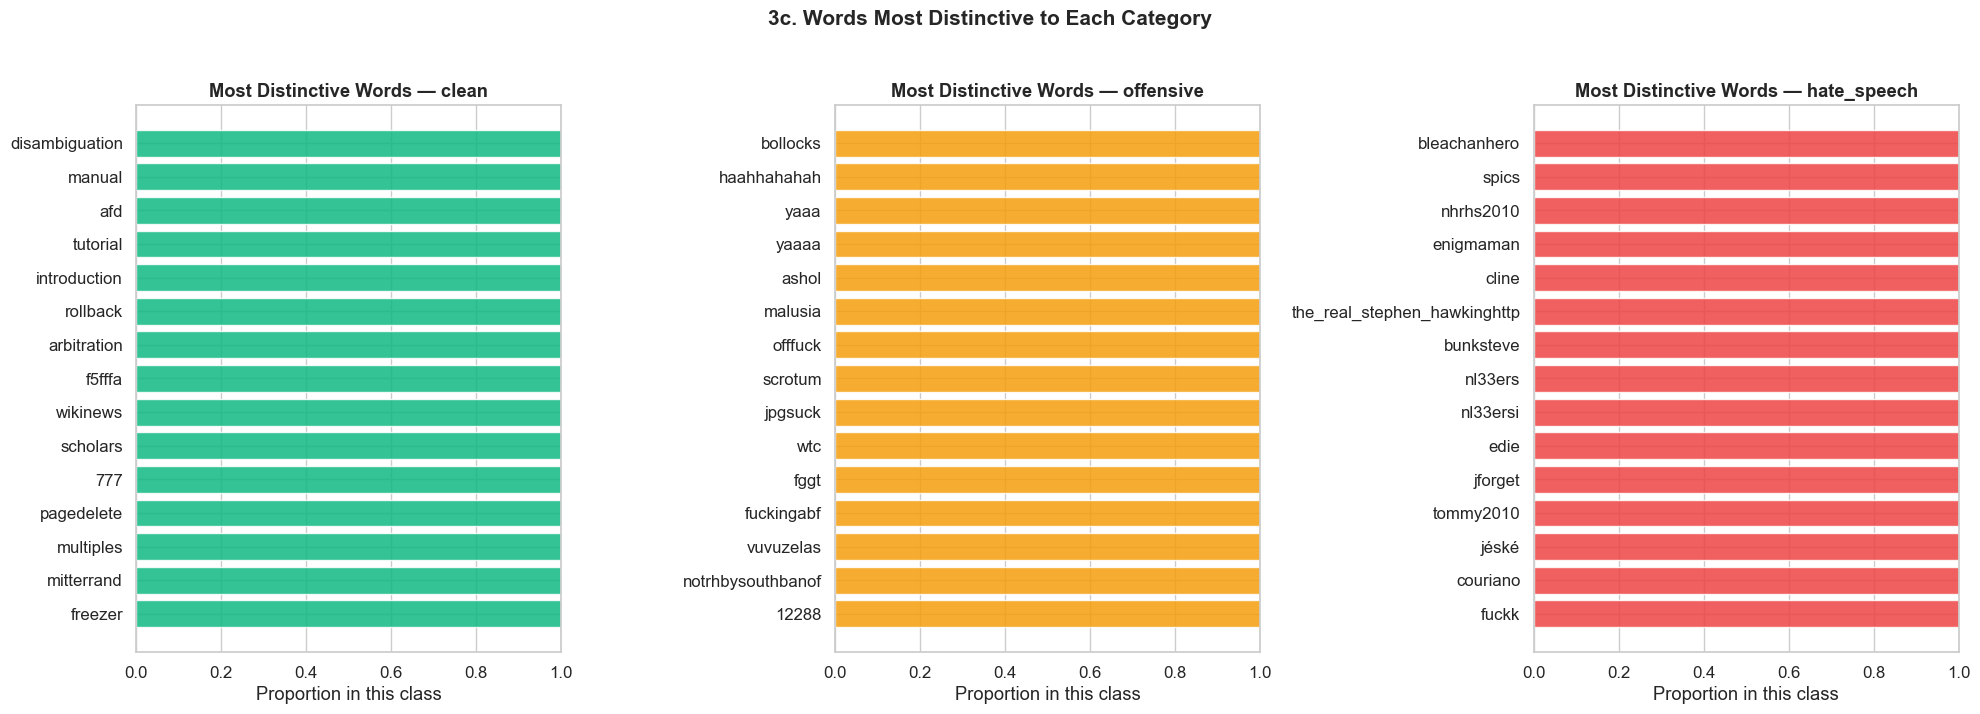

In [8]:
# 3c — Unique / distinctive words per category (words that appear much more in one class)
all_words = {}
for label in ["clean", "offensive", "hate_speech"]:
    subset = balanced[balanced["label"] == label]["text"]
    words = []
    for t in subset:
        t = re.sub(r"[^\w\s]", " ", str(t).lower())
        words.extend([w for w in t.split() if w not in stop_words and len(w) > 2])
    all_words[label] = Counter(words)

total = sum(all_words.values(), Counter())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for i, label in enumerate(["clean", "offensive", "hate_speech"]):
    ratios = {}
    for word, count in all_words[label].items():
        if total[word] >= 20:
            ratios[word] = count / total[word]
    top_distinct = sorted(ratios.items(), key=lambda x: -x[1])[:15]
    words, scores = zip(*top_distinct)
    y_pos = range(len(words))
    axes[i].barh(y_pos, scores, color=COLORS[label], edgecolor="white", alpha=0.85)
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f"Most Distinctive Words — {label}", fontweight="bold")
    axes[i].set_xlabel("Proportion in this class")
    axes[i].set_xlim(0, 1)

plt.suptitle("3c. Words Most Distinctive to Each Category", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. TF-IDF Feature Analysis

We examine the top TF-IDF weighted terms for each class, which directly validates the feature engineering choices in `build_features.py` (ngram_range=(1,2), max_features=20,000).

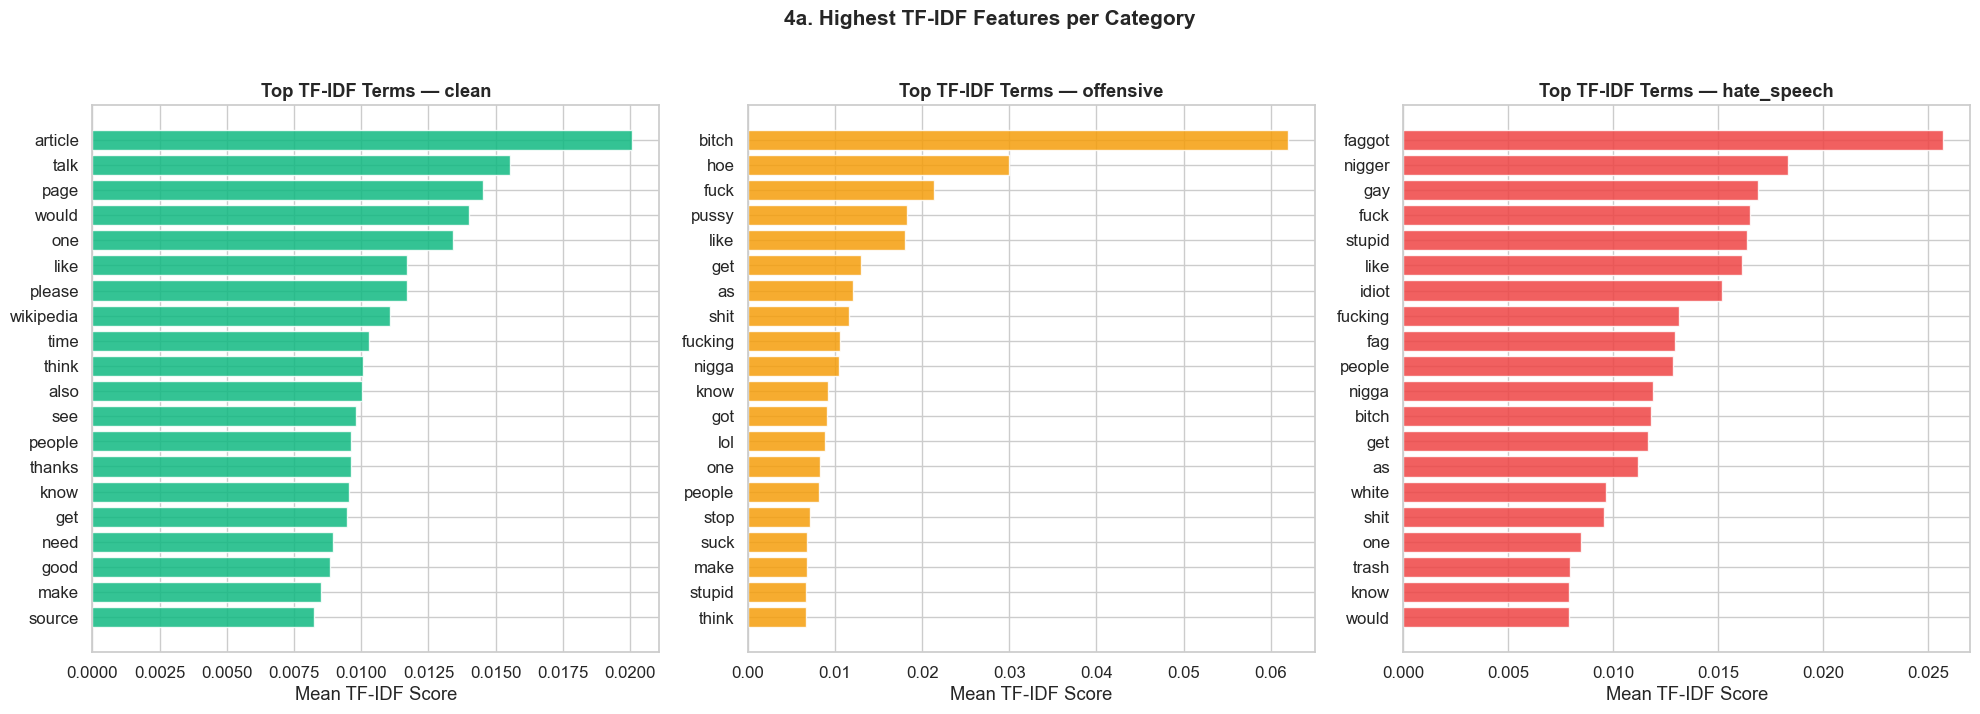


Total vocabulary size: 17,000
TF-IDF matrix shape: (13588, 17000)
Sparsity: 99.8834%


In [9]:
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")
X_train_tfidf = sparse.load_npz(DATA_DIR / "processed" / "X_train_tfidf.npz")
feature_names = np.array(vectorizer.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
label_names = ["clean", "offensive", "hate_speech"]

for i, label in enumerate(label_names):
    mask = train_df["label"] == label
    mean_tfidf = X_train_tfidf[mask.values].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-20:][::-1]
    top_words = feature_names[top_idx]
    top_scores = mean_tfidf[top_idx]

    y_pos = range(len(top_words))
    axes[i].barh(y_pos, top_scores, color=COLORS[label], edgecolor="white", alpha=0.85)
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(top_words)
    axes[i].invert_yaxis()
    axes[i].set_title(f"Top TF-IDF Terms — {label}", fontweight="bold")
    axes[i].set_xlabel("Mean TF-IDF Score")

plt.suptitle("4a. Highest TF-IDF Features per Category", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTotal vocabulary size: {len(feature_names):,}")
print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.4%}")

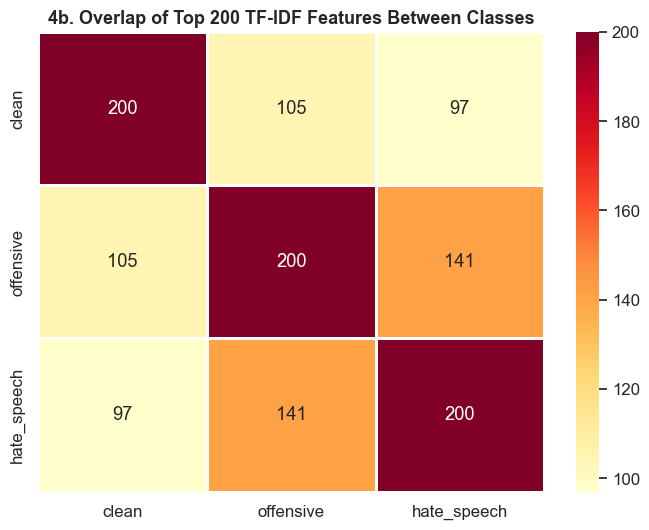

In [10]:
# 4b — TF-IDF feature overlap heatmap: how many top features are shared between classes
top_n = 200
top_per_class = {}
for label in label_names:
    mask = train_df["label"] == label
    mean_tfidf = X_train_tfidf[mask.values].mean(axis=0).A1
    top_per_class[label] = set(mean_tfidf.argsort()[-top_n:])

overlap_matrix = np.zeros((3, 3))
for i, l1 in enumerate(label_names):
    for j, l2 in enumerate(label_names):
        overlap_matrix[i, j] = len(top_per_class[l1] & top_per_class[l2])

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", cmap="YlOrRd",
            xticklabels=label_names, yticklabels=label_names, ax=ax,
            linewidths=2, linecolor="white")
ax.set_title(f"4b. Overlap of Top {top_n} TF-IDF Features Between Classes", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Handcrafted Features Analysis

Our `build_features.py` extracts 7 handcrafted features: `char_count`, `word_count`, `avg_word_len`, `uppercase_ratio`, `exclamation_count`, `question_count`, `caps_word_count`. We visualize their distributions to see which features discriminate between labels.

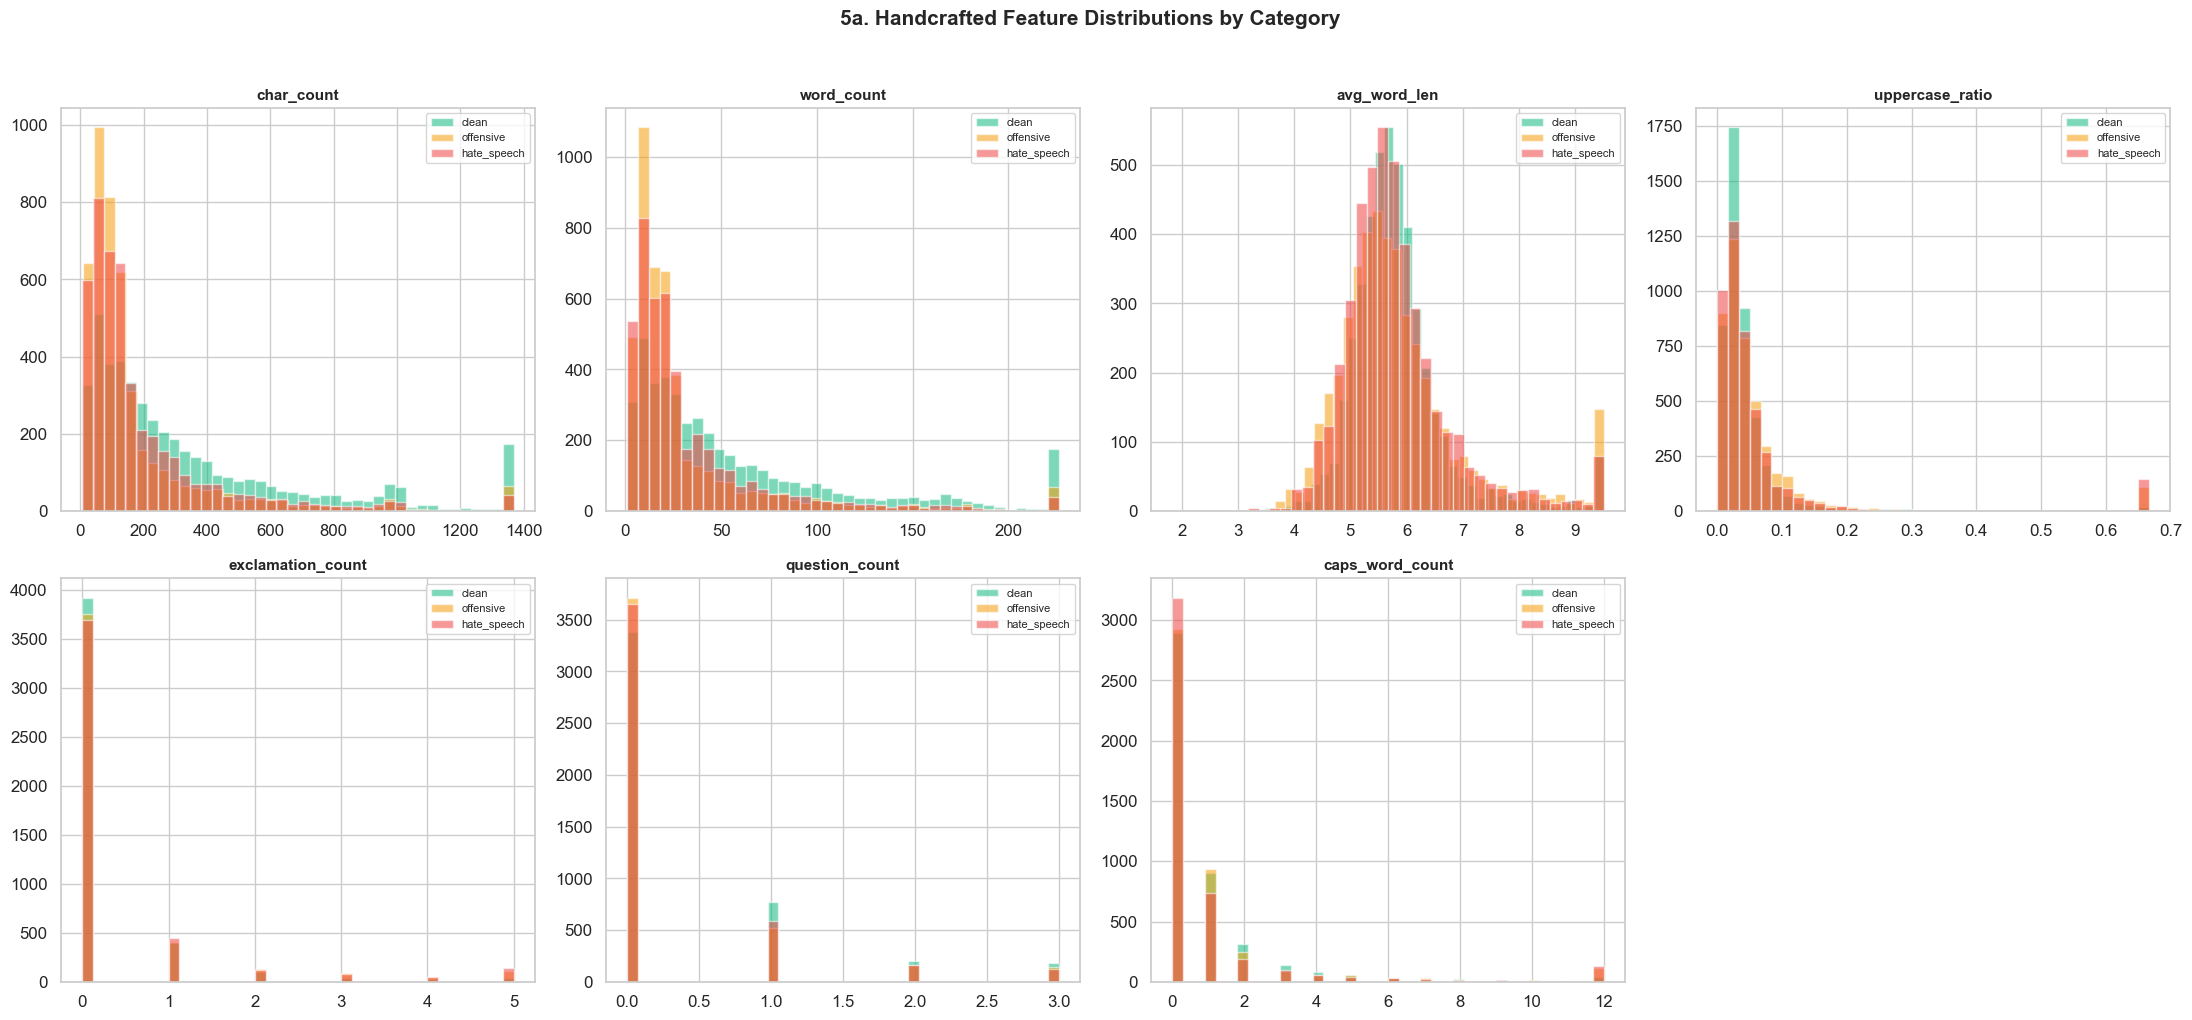

In [11]:
train_hc = pd.read_csv(DATA_DIR / "processed" / "train_handcrafted.csv")
train_hc["label"] = train_df["label"].values

feature_cols = train_hc.columns.drop("label")

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    for label in ["clean", "offensive", "hate_speech"]:
        subset = train_hc[train_hc["label"] == label][col].clip(upper=train_hc[col].quantile(0.98))
        ax.hist(subset, bins=40, alpha=0.55, label=label, color=COLORS[label], edgecolor="white")
    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)

# Hide unused subplot
if len(feature_cols) < len(axes):
    for j in range(len(feature_cols), len(axes)):
        axes[j].set_visible(False)

plt.suptitle("5a. Handcrafted Feature Distributions by Category", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

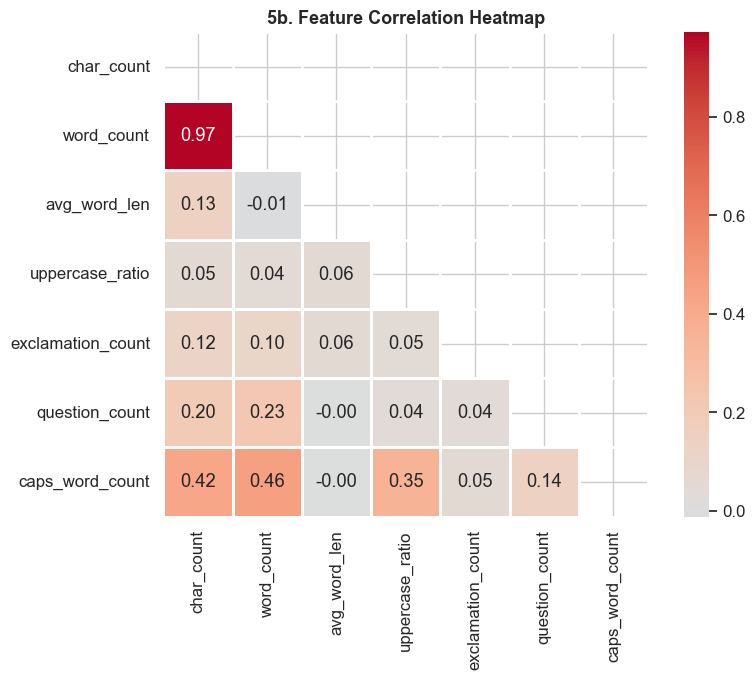

In [12]:
# 5b — Correlation heatmap of handcrafted features
fig, ax = plt.subplots(figsize=(9, 7))
corr = train_hc[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax, linewidths=1, linecolor="white", square=True)
ax.set_title("5b. Feature Correlation Heatmap", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

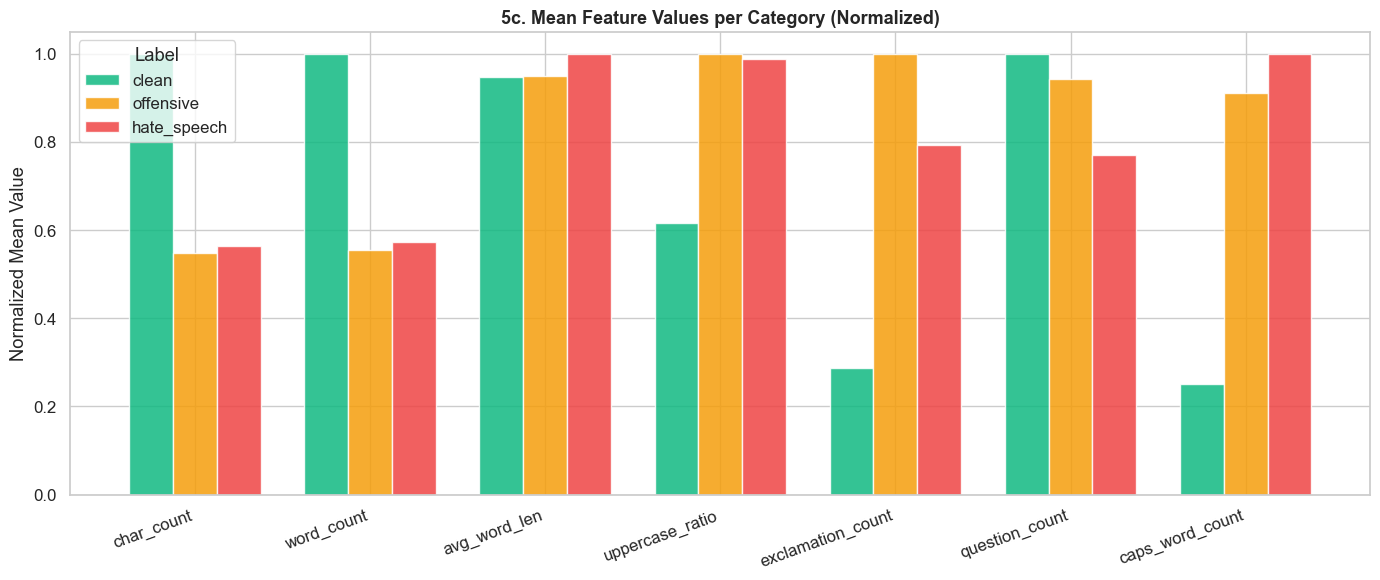

In [13]:
# 5c — Mean feature values per class (grouped bar chart)
mean_by_label = train_hc.groupby("label")[feature_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(feature_cols))
width = 0.25

for i, label in enumerate(["clean", "offensive", "hate_speech"]):
    vals = mean_by_label.loc[label].values
    # Normalize to [0,1] for visual comparison
    vals_norm = vals / mean_by_label.max().values
    ax.bar(x + i * width, vals_norm, width, label=label, color=COLORS[label], edgecolor="white", alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(feature_cols, rotation=20, ha="right")
ax.set_ylabel("Normalized Mean Value")
ax.set_title("5c. Mean Feature Values per Category (Normalized)", fontweight="bold", fontsize=13)
ax.legend(title="Label")
plt.tight_layout()
plt.show()

## 6. Data Source Comparison

Since we merged three different data sources (Davidson, Jigsaw v1, Jigsaw v2), we need to understand whether their text distributions are consistent. Mismatches could hurt model generalization.

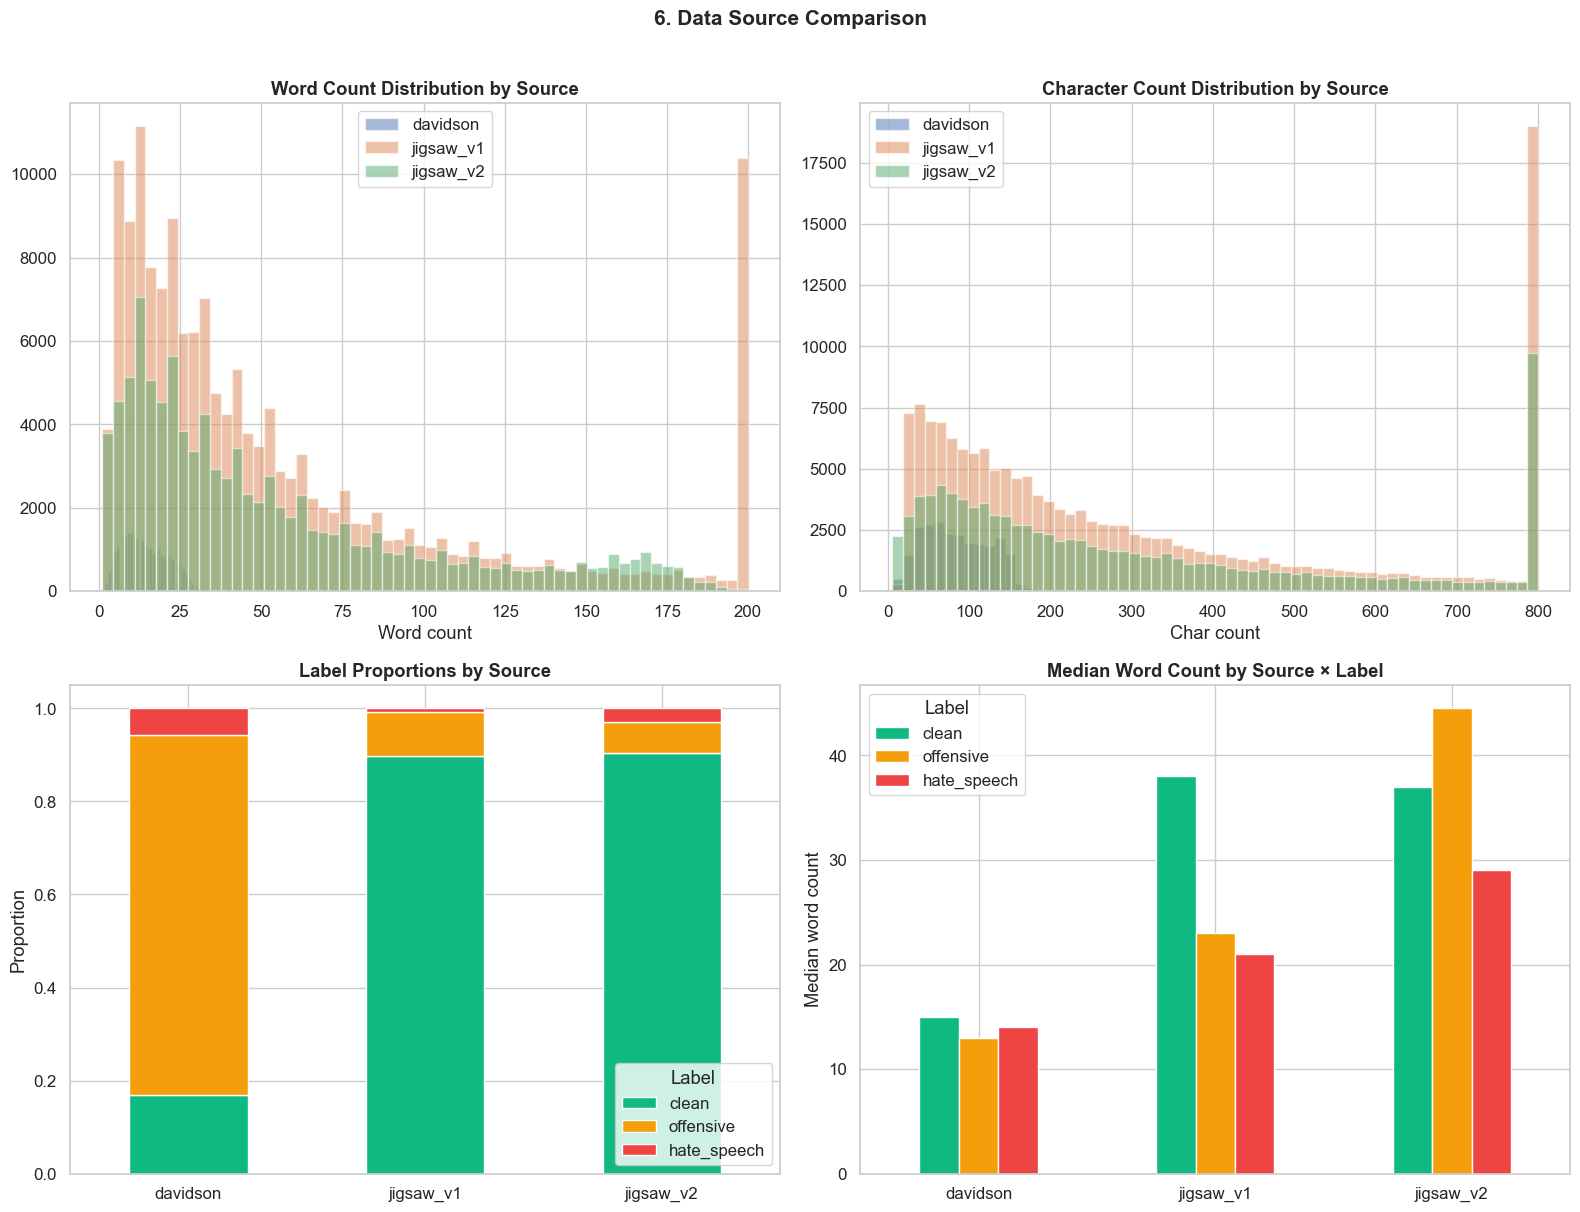


Samples per source:
source
jigsaw_v1    159571
jigsaw_v2     99669
davidson      24781
Name: count, dtype: int64

Davidson avg words: 14.1
Jigsaw v1 avg words: 67.3
Jigsaw v2 avg words: 53.6


In [14]:
unified["char_count"] = unified["text"].str.len()
unified["word_count"] = unified["text"].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 6a — Word count distribution per source
for src in unified["source"].unique():
    subset = unified[unified["source"] == src]["word_count"].clip(upper=200)
    axes[0, 0].hist(subset, bins=60, alpha=0.5, label=src, edgecolor="white")
axes[0, 0].set_title("Word Count Distribution by Source", fontweight="bold")
axes[0, 0].set_xlabel("Word count")
axes[0, 0].legend()

# 6b — Char count distribution per source
for src in unified["source"].unique():
    subset = unified[unified["source"] == src]["char_count"].clip(upper=800)
    axes[0, 1].hist(subset, bins=60, alpha=0.5, label=src, edgecolor="white")
axes[0, 1].set_title("Character Count Distribution by Source", fontweight="bold")
axes[0, 1].set_xlabel("Char count")
axes[0, 1].legend()

# 6c — Label proportions per source (normalized stacked bar)
cross_norm = pd.crosstab(unified["source"], unified["label"], normalize="index")
cross_norm = cross_norm[["clean", "offensive", "hate_speech"]]
cross_norm.plot(kind="bar", stacked=True, color=PALETTE, edgecolor="white", ax=axes[1, 0])
axes[1, 0].set_title("Label Proportions by Source", fontweight="bold")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].set_xlabel("")
axes[1, 0].legend(title="Label")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# 6d — Median text length by source and label
median_lens = unified.groupby(["source", "label"])["word_count"].median().unstack()
median_lens = median_lens[["clean", "offensive", "hate_speech"]]
median_lens.plot(kind="bar", color=PALETTE, edgecolor="white", ax=axes[1, 1])
axes[1, 1].set_title("Median Word Count by Source × Label", fontweight="bold")
axes[1, 1].set_ylabel("Median word count")
axes[1, 1].set_xlabel("")
axes[1, 1].legend(title="Label")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.suptitle("6. Data Source Comparison", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nSamples per source:")
print(unified["source"].value_counts())
print(f"\nDavidson avg words: {unified[unified['source']=='davidson']['word_count'].mean():.1f}")
print(f"Jigsaw v1 avg words: {unified[unified['source']=='jigsaw_v1']['word_count'].mean():.1f}")
print(f"Jigsaw v2 avg words: {unified[unified['source']=='jigsaw_v2']['word_count'].mean():.1f}")

## 7. Error Analysis Preview

We load the model evaluation results and visualize the confusion matrices and model comparison, providing context for the error analysis in the report.

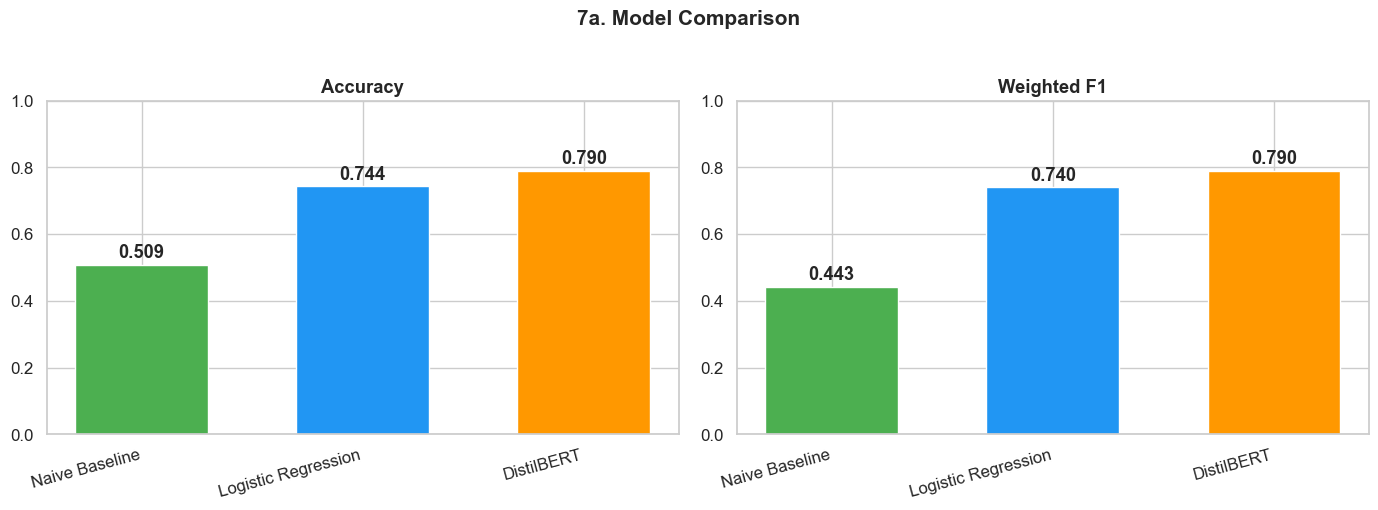

In [15]:
import json

OUTPUTS_DIR = DATA_DIR / "outputs"

with open(OUTPUTS_DIR / "full_results.json") as f:
    results = json.load(f)

comparison = pd.read_csv(OUTPUTS_DIR / "model_comparison.csv")

# 7a — Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison["Model"]
x = np.arange(len(models))

bars1 = axes[0].bar(x, comparison["Accuracy"], color=["#4CAF50", "#2196F3", "#FF9800"], edgecolor="white", width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha="right")
axes[0].set_title("Accuracy", fontweight="bold")
axes[0].set_ylim(0, 1)
for bar, v in zip(bars1, comparison["Accuracy"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

bars2 = axes[1].bar(x, comparison["Weighted F1"], color=["#4CAF50", "#2196F3", "#FF9800"], edgecolor="white", width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15, ha="right")
axes[1].set_title("Weighted F1", fontweight="bold")
axes[1].set_ylim(0, 1)
for bar, v in zip(bars2, comparison["Weighted F1"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.suptitle("7a. Model Comparison", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

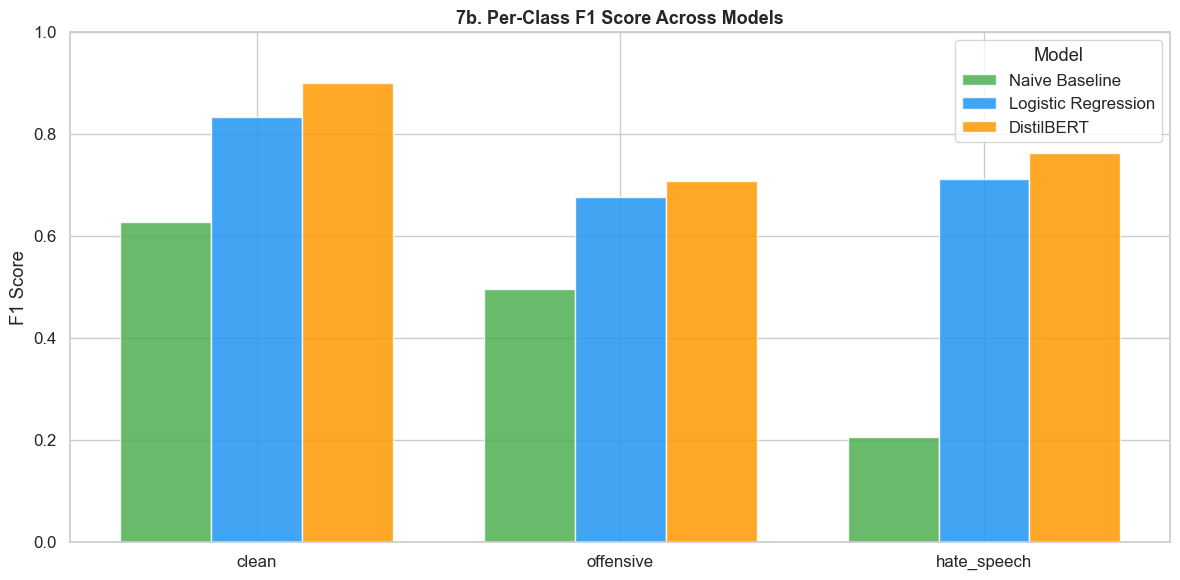

In [16]:
# 7b — Per-class F1 comparison across models (grouped bar)
label_names = ["clean", "offensive", "hate_speech"]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(label_names))
width = 0.25
model_colors = ["#4CAF50", "#2196F3", "#FF9800"]

for i, r in enumerate(results):
    f1s = [r["report"][l]["f1-score"] for l in label_names]
    ax.bar(x + i * width, f1s, width, label=r["model"], color=model_colors[i], edgecolor="white", alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(label_names)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
ax.set_title("7b. Per-Class F1 Score Across Models", fontweight="bold", fontsize=13)
ax.legend(title="Model")
plt.tight_layout()
plt.show()

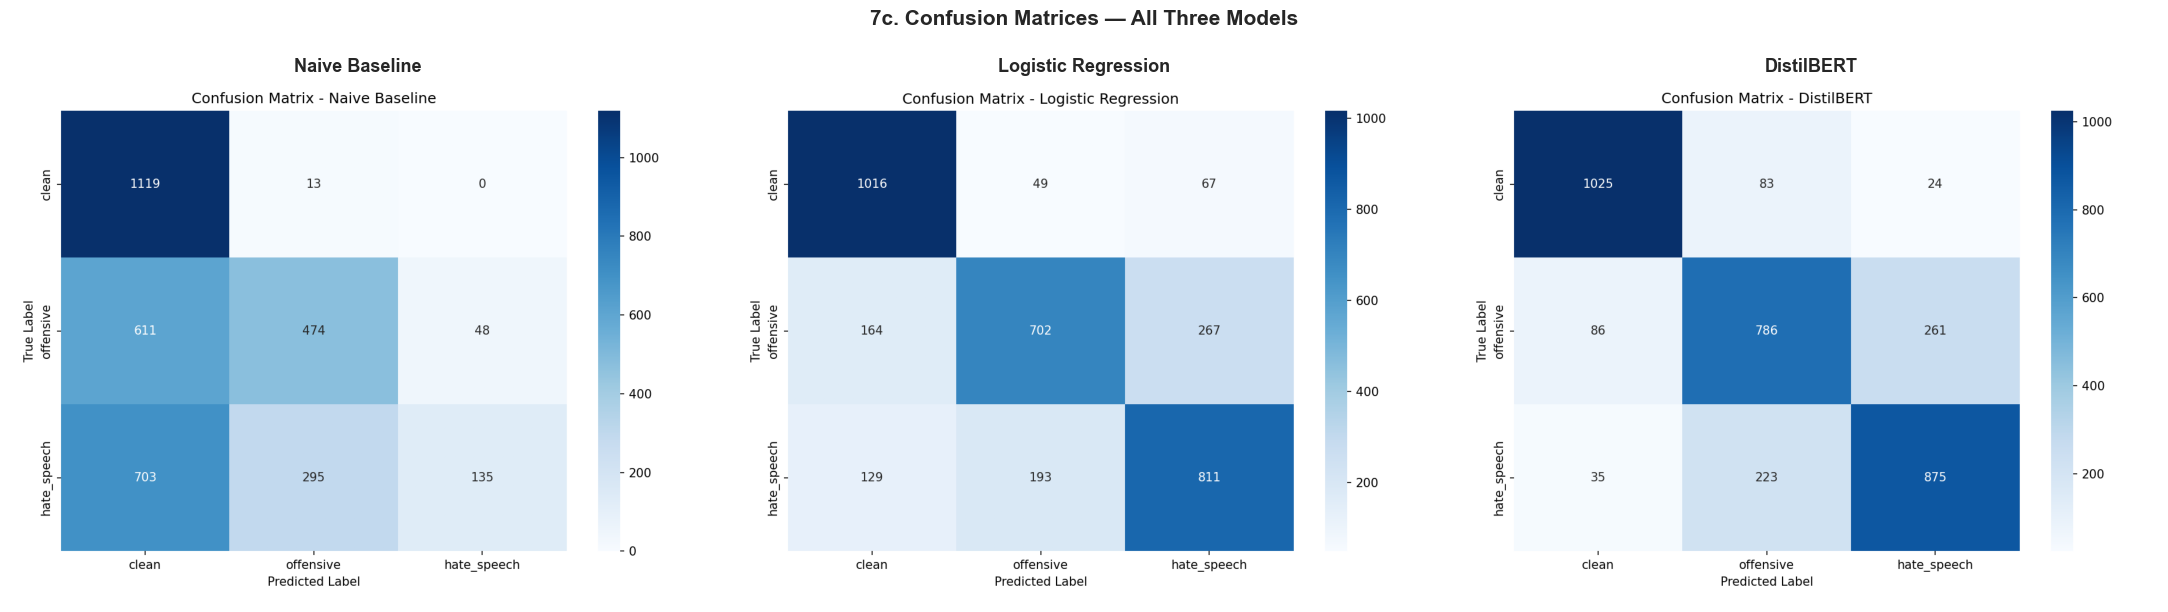

In [17]:
# 7c — Display saved confusion matrices side by side
from matplotlib.image import imread

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
cm_files = [
    ("confusion_matrix_naive_baseline.png", "Naive Baseline"),
    ("confusion_matrix_logistic_regression.png", "Logistic Regression"),
    ("confusion_matrix_distilbert.png", "DistilBERT"),
]
for i, (fname, title) in enumerate(cm_files):
    img = imread(OUTPUTS_DIR / fname)
    axes[i].imshow(img)
    axes[i].set_title(title, fontweight="bold", fontsize=13)
    axes[i].axis("off")

plt.suptitle("7c. Confusion Matrices — All Three Models", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

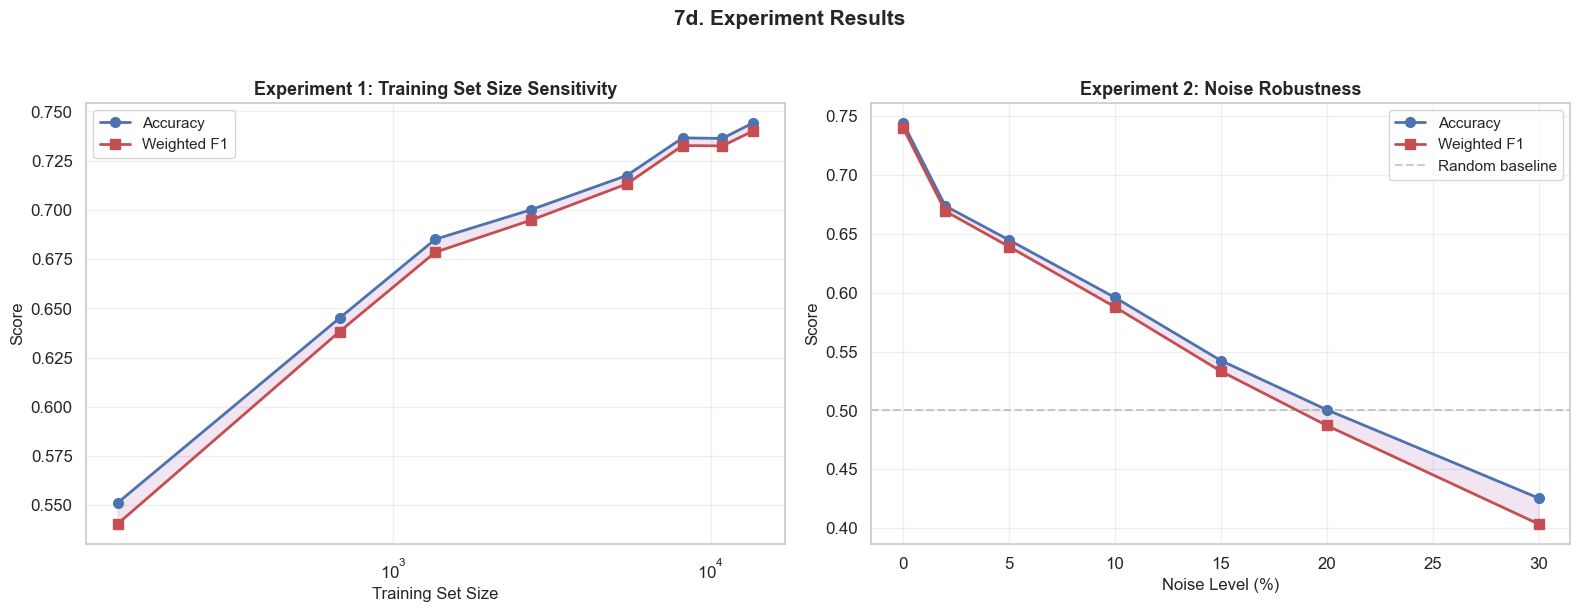

In [18]:
# 7d — Experiment results visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training size sensitivity
exp_size = pd.read_csv(OUTPUTS_DIR / "experiment_training_size.csv")
axes[0].plot(exp_size["n_samples"], exp_size["accuracy"], "b-o", label="Accuracy", linewidth=2, markersize=7)
axes[0].plot(exp_size["n_samples"], exp_size["weighted_f1"], "r-s", label="Weighted F1", linewidth=2, markersize=7)
axes[0].fill_between(exp_size["n_samples"], exp_size["accuracy"], exp_size["weighted_f1"], alpha=0.1, color="purple")
axes[0].set_xlabel("Training Set Size", fontsize=12)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("Experiment 1: Training Set Size Sensitivity", fontweight="bold", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

# Noise robustness
exp_noise = pd.read_csv(OUTPUTS_DIR / "experiment_noise_robustness.csv")
axes[1].plot(exp_noise["noise_level"] * 100, exp_noise["accuracy"], "b-o", label="Accuracy", linewidth=2, markersize=7)
axes[1].plot(exp_noise["noise_level"] * 100, exp_noise["weighted_f1"], "r-s", label="Weighted F1", linewidth=2, markersize=7)
axes[1].fill_between(exp_noise["noise_level"] * 100, exp_noise["accuracy"], exp_noise["weighted_f1"], alpha=0.1, color="purple")
axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="Random baseline")
axes[1].set_xlabel("Noise Level (%)", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("Experiment 2: Noise Robustness", fontweight="bold", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle("7d. Experiment Results", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

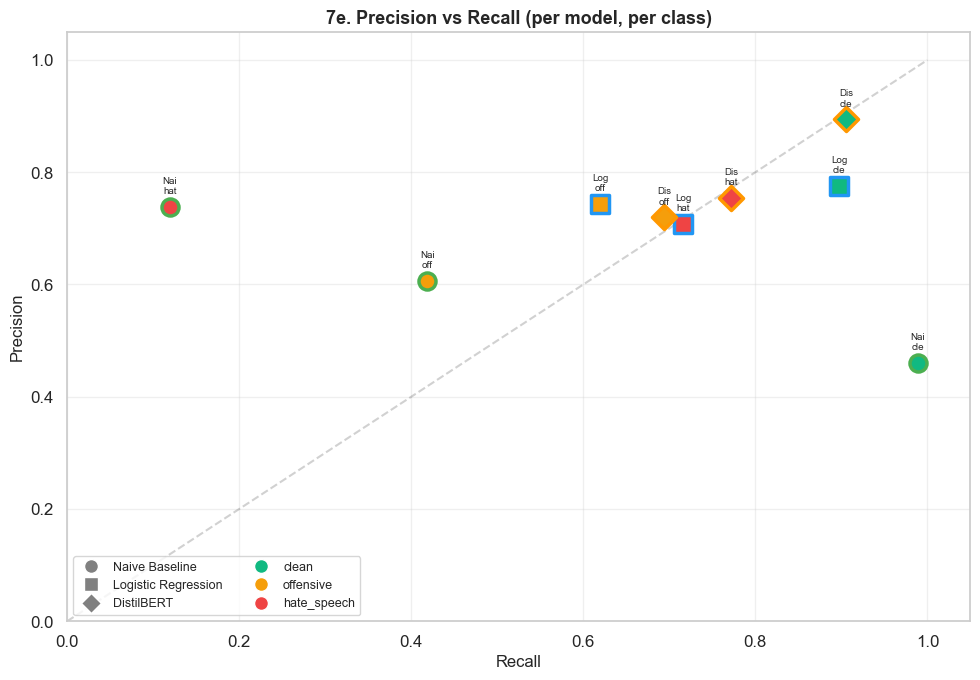

In [19]:
# 7e — Precision vs Recall scatter per model per class
fig, ax = plt.subplots(figsize=(10, 7))
markers = {"Naive Baseline": "o", "Logistic Regression": "s", "DistilBERT": "D"}
model_colors_map = {"Naive Baseline": "#4CAF50", "Logistic Regression": "#2196F3", "DistilBERT": "#FF9800"}

for r in results:
    for label in label_names:
        prec = r["report"][label]["precision"]
        rec = r["report"][label]["recall"]
        ax.scatter(rec, prec, s=150, marker=markers[r["model"]],
                   color=COLORS[label], edgecolors=model_colors_map[r["model"]], linewidths=2.5,
                   zorder=3)
        ax.annotate(f'{r["model"][:3]}\n{label[:3]}', (rec, prec),
                    fontsize=7, ha="center", va="bottom", textcoords="offset points", xytext=(0, 8))

ax.plot([0, 1], [0, 1], "k--", alpha=0.2)
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("7e. Precision vs Recall (per model, per class)", fontweight="bold", fontsize=13)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=10, label="Naive Baseline"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=10, label="Logistic Regression"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="gray", markersize=10, label="DistilBERT"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["clean"], markersize=10, label="clean"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["offensive"], markersize=10, label="offensive"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["hate_speech"], markersize=10, label="hate_speech"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Class imbalance** — Raw data is 84% clean vs 2% hate_speech (42:1 ratio). Balanced sampling is critical.
2. **Text length** — Davidson tweets are short (~20 words), Jigsaw comments are long (~50-80 words). DistilBERT's 128-token limit covers 95%+ of texts.
3. **Keyword overlap** — Offensive and hate_speech share many keywords, explaining why the Naive Baseline struggles to distinguish them.
4. **TF-IDF** — Each class has distinctive vocabulary. The offensive/hate_speech overlap in top TF-IDF features explains the confusion between these two classes.
5. **Handcrafted features** — `uppercase_ratio` and `caps_word_count` show the strongest separation between categories, validating their inclusion.
6. **Data source differences** — Davidson (tweets) and Jigsaw (comments) have very different text lengths and styles. Combining them adds diversity but also introduces distribution variance.
7. **Model progression** — Clear improvement from Naive (F1=0.44) → LR (F1=0.74) → DistilBERT (F1=0.79). The biggest confusion is between offensive and hate_speech across all models.